## Import Libraries

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

import warnings
warnings.filterwarnings("ignore")

In [2]:
## Load dataset
df = pd.read_csv("C:/Users/LENOVO/Downloads/ecommerce_sales_analytics.csv")
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10.0,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6.0,3.9,304.10
2,10003,1/3/2022,1860,Beauty,NaN,3,311.28,0.31,COD,6.0,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,NaN,Wallet,6.0,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4.0,4.9,468.56


## Data Modelling

In [3]:
df.shape

(5000, 12)

In [4]:
df.columns

Index(['order_id', 'order_date', 'customer_id', 'product_category', 'region',
       'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days',
       'customer_rating', 'revenue'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            4850 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          4700 non-null   float64
 8   payment_method    4800 non-null   object 
 9   delivery_days     4750 non-null   float64
 10  customer_rating   4600 non-null   float64
 11  revenue           4900 non-null   float64
dtypes: float64(5), int64(3), object(4)
memory usage: 468.9+ KB


In [6]:
# Statistical summary
df.describe(include='all').round(2)

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
count,5000.00,5000,5000.00,5000,4850,5000.00,5000.00,4700.00,4800,4750.00,4600.00,4900.00
unique,NaN,5000,NaN,4,4,NaN,NaN,NaN,3,NaN,NaN,NaN
top,NaN,1/1/2022,NaN,Electronics,North,NaN,NaN,NaN,Card,NaN,NaN,NaN
freq,NaN,1,NaN,1777,1247,NaN,NaN,NaN,2173,NaN,NaN,NaN
mean,12500.50,NaN,1505.70,NaN,NaN,4.04,308.42,0.18,NaN,6.12,2.98,1020.00
std,1443.52,NaN,290.84,NaN,NaN,2.02,169.26,0.10,NaN,3.16,1.15,824.30
min,10001.00,NaN,1000.00,NaN,NaN,1.00,15.15,0.00,NaN,1.00,1.00,11.21
25%,11250.75,NaN,1253.00,NaN,NaN,2.00,161.90,0.09,NaN,3.00,2.00,353.99
50%,12500.50,NaN,1510.00,NaN,NaN,4.00,309.89,0.18,NaN,6.00,3.00,794.88
75%,13750.25,NaN,1761.00,NaN,NaN,6.00,455.56,0.27,NaN,9.00,4.00,1512.18


In [7]:
#Missing Values
df.isnull().sum()

order_id              0
order_date            0
customer_id           0
product_category      0
region              150
quantity              0
unit_price            0
discount            300
payment_method      200
delivery_days       250
customer_rating     400
revenue             100
dtype: int64

In [8]:
# Duplicate Records
df.duplicated().sum()

np.int64(0)

## Data Cleaning

In [9]:
#Convert Date Column
df["order_date"] = pd.to_datetime(df["order_date"])

In [10]:
#Remove Duplicates
df = df.drop_duplicates()

In [11]:
# Check Missing Values
df.isnull().sum()

order_id              0
order_date            0
customer_id           0
product_category      0
region              150
quantity              0
unit_price            0
discount            300
payment_method      200
delivery_days       250
customer_rating     400
revenue             100
dtype: int64

In [12]:
# Fill Numerical Columns with Median
num_cols = ["discount", "delivery_days", "customer_rating", "revenue"]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [13]:
# Fill Categorical Columns with Mode
cat_cols = ["region", "payment_method"]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [14]:
# recheck missing value
df.isnull().sum()

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

In [15]:
# Create Year, Month, Month_Name, and Day columns from order_date
df["Year"] = df["order_date"].dt.year
df["Month"] = df["order_date"].dt.month
df["Month_Name"] = df["order_date"].dt.month_name()
df["Day"] = df["order_date"].dt.day

## Exploratory Data Analysis (EDA)

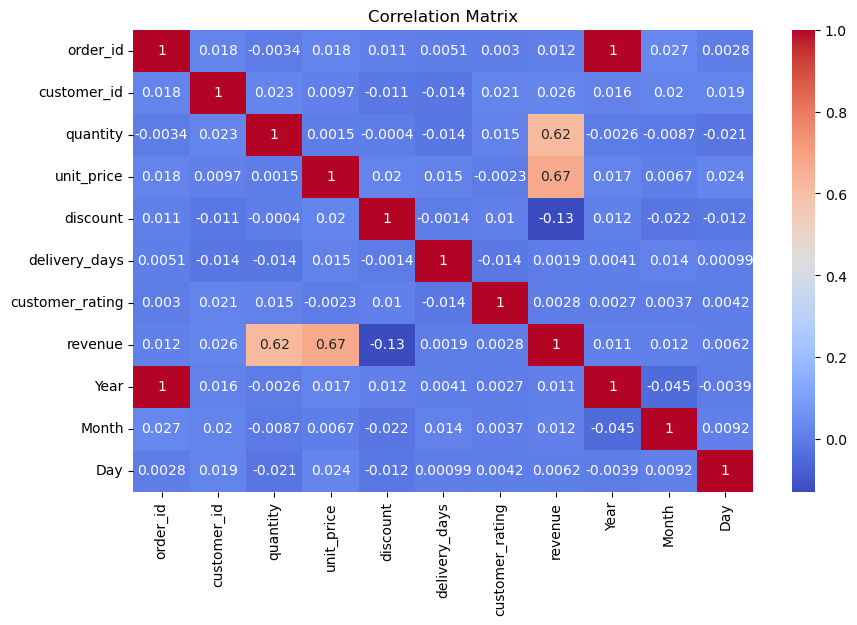

In [16]:
# Correlation Matrix
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

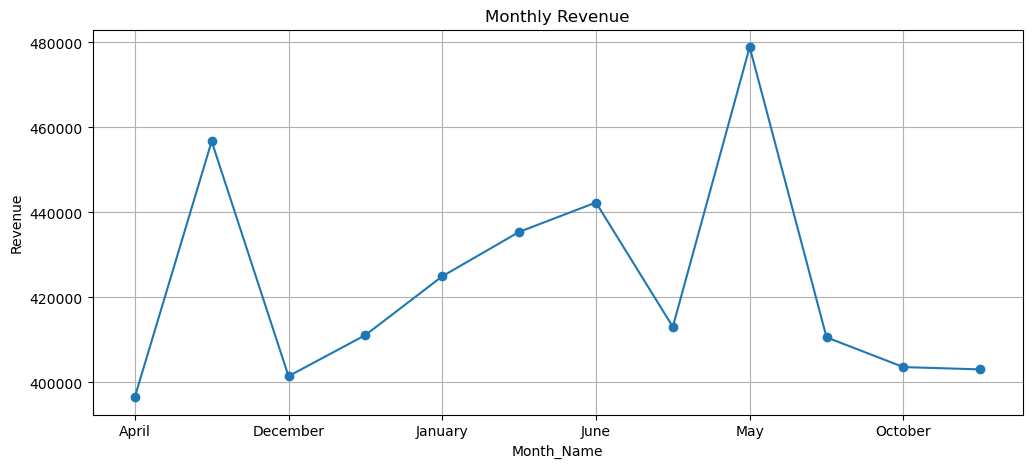

In [17]:
# Monthly Revenue Trend
monthly_sales = df.groupby("Month_Name")["revenue"].sum()

plt.figure(figsize=(12,5))

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Revenue")

plt.ylabel("Revenue")

plt.grid()

plt.show()

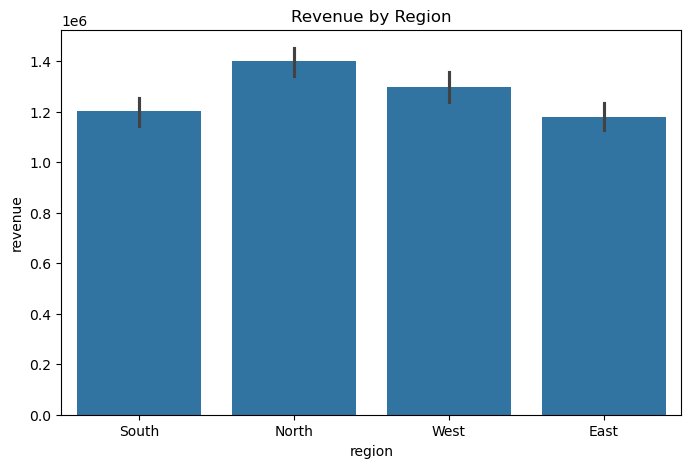

In [18]:
# # Create a bar chart showing total revenue by region
plt.figure(figsize=(8,5))

sns.barplot(data=df,
            x="region",
            y="revenue",
            estimator=sum)

plt.title("Revenue by Region")

plt.show()

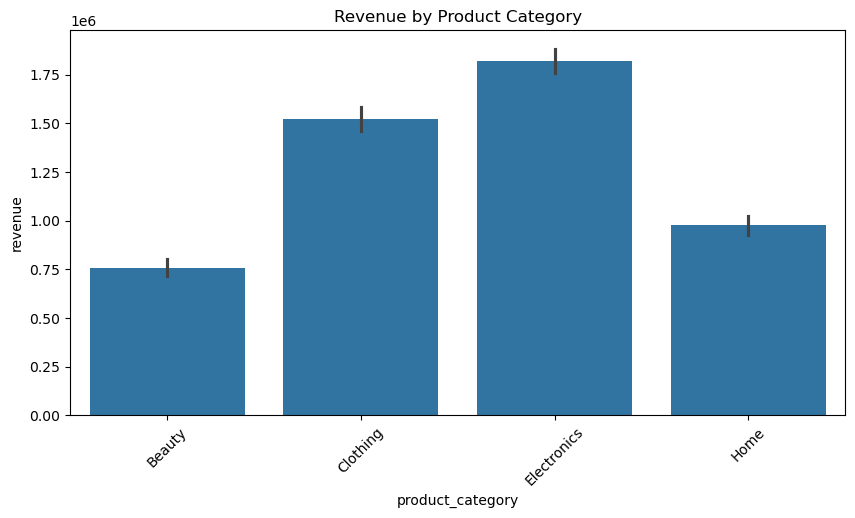

In [19]:
# Create a bar chart showing total revenue by product category
plt.figure(figsize=(10,5))

sns.barplot(data=df,
            x="product_category",
            y="revenue",
            estimator=sum)

plt.xticks(rotation=45)

plt.title("Revenue by Product Category")

plt.show()

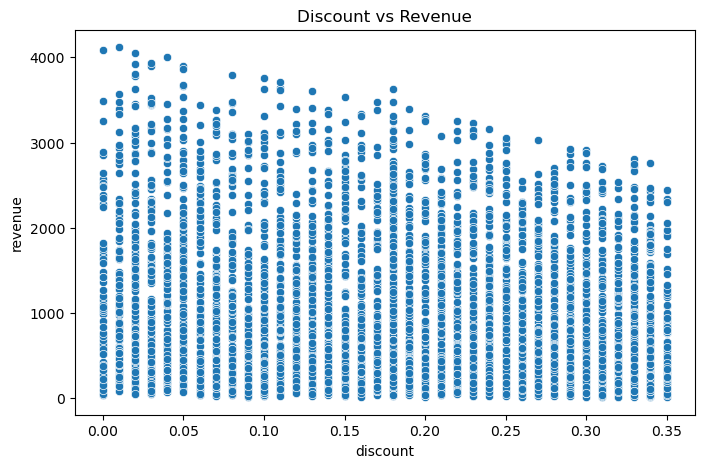

In [20]:
# Create a scatter plot to visualize the relationship between discount and revenue
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="discount",
    y="revenue"
)

plt.title("Discount vs Revenue")

plt.show()

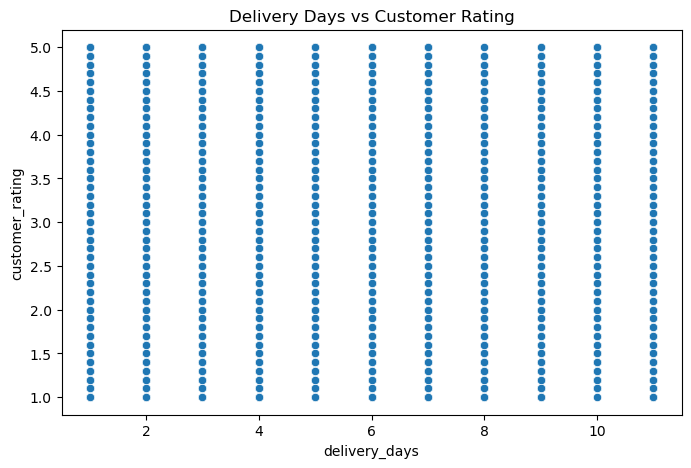

In [21]:
# Create a scatter plot to visualize the relationship between delivery days and customer ratings
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="delivery_days",
    y="customer_rating"
)

plt.title("Delivery Days vs Customer Rating")

plt.show()

## Load data to mysql

In [22]:
!pip install pymysql sqlalchemy

In [23]:
from sqlalchemy import create_engine

username = "root"
password = "#your_password"
host     = "localhost"
port     = "3306"
database = "ecommerce_sales" 

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

df.to_sql("customer", engine, if_exists="replace", index=False)

pd.read_sql("SELECT * FROM customer LIMIT 5;", engine)

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,Year,Month,Month_Name,Day
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10.0,4.7,1883.20,2022,1,January,1
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6.0,3.9,304.10,2022,1,January,2
2,10003,2022-01-03,1860,Beauty,North,3,311.28,0.31,COD,6.0,2.5,644.35,2022,1,January,3
3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.18,Wallet,6.0,1.6,2569.90,2022,1,January,4
4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4.0,4.9,468.56,2022,1,January,5


In [24]:
from sqlalchemy import create_engine
import pandas as pd

username = "root"
password = "#your_password"
host     = "localhost"
port     = "3306"
database = "customer_behavior"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

df.to_sql("customer", engine, if_exists="replace", index=False)

print("Done")

Done
